In [1]:
#Import all relevant packages
import CalculatedFieldSubroutines as cfs

#

import numpy as np

import pandas as pd

import random

#

from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import KFold

from sklearn.metrics import confusion_matrix

#

from bayes_opt import BayesianOptimization

#

import matplotlib.pyplot as plt

import cartopy.crs as ccrs

from cartopy.io.img_tiles import GoogleTiles

from pandasgui import show

#

import warnings

from imblearn.under_sampling import RandomUnderSampler

In [2]:
## Hyperparameter Tuning Setup
##Set "moving_windows" equal to 0
##Set "routes" equal to "Red", "Green", "Blue"; for the red, green, and blue routes found in this dataset
##Set "X_colnames" equal to the column names of the predictor variables
##Set "y_colnamesy equal to the column name of the target variables
##Set "metric_function" equal to cfs.mf_accuracy" (which will be used to calculate the accuacies of the trees
##Set the maximum number of splits ("cv_num_of_splits") equal to 5

moving_windows = [0] # sec

routes = [ 'Red', 'Green', 'Blue' ]

X_colnames = [ 'speedMps', 'brakePercentage', 'throttlePercentage', 'steeringPercentage', 'LatLonTotalStdDev' ]

y_colname = 'BinaryDrivingMode'

metric_function = cfs.mf_accuracy

cv_num_of_splits = 5

In [3]:
##Extract gmIDs, saving them in "gmID_list"
gmID_list = cfs.list_whitelisted_gmIDs()

#
##Set "red_training_gmIDs" equal to a list gmIDs invovling the red route
##Set "green_training_gmIDs" equal to a list gmIDs invovling the green route
##Set "blue_training_gmIDs" equal to a list gmIDs invovling the blue route
red_training_gmIDs = [
'61b12e7a-f234-11ee-bb33-fb353e7798cd',
'fcc6fcd2-f013-11ee-b966-fb353e7798cd',
'05c7c824-cab8-11ee-aa4d-1d66adf2f0c7',
'211bdb36-f0da-11ee-ba1b-fb353e7798cd',
'868de15e-f3b3-11ee-bb4e-fb353e7798cd',
'72a03d4a-efe9-11ee-b966-fb353e7798cd',
'7fb7b9c0-c881-11ee-a7fc-dd032dba19e8',
'96f7a614-f549-11ee-8afa-cb629b0d53e6',
'1bbbfbae-c839-11ee-a7fc-dd032dba19e8',
'622bd2e8-f0e4-11ee-ba1f-fb353e7798cd',
'9798fe24-f143-11ee-ba78-fb353e7798cd',
'88dd6fbe-f224-11ee-bb21-fb353e7798cd',
'c9c6856c-d33c-11ee-b437-336917683bb8',
'd12cd1c4-caec-11ee-909c-e1dc60cf66f9',
'817d6848-efb6-11ee-b966-fb353e7798cd',
'1b6aca0e-efdf-11ee-b966-fb353e7798cd',
'41b67a28-f52f-11ee-8afa-cb629b0d53e6',
'fc211bb2-efca-11ee-b966-fb353e7798cd',
'84d96f18-f214-11ee-bb13-fb353e7798cd',
'fe973c9c-f53c-11ee-8afa-cb629b0d53e6',
'3151e9e2-eff3-11ee-b966-fb353e7798cd',
'c0555ef0-f50f-11ee-8afa-cb629b0d53e6',
'f711e68e-f0e1-11ee-ba1f-fb353e7798cd',
'c338788a-d324-11ee-b437-336917683bb8',
'd21965e6-f0fa-11ee-ba37-fb353e7798cd',
'88a68dd8-eef9-11ee-9385-ef789ffde1d3',
'f41cbd44-eff8-11ee-b966-fb353e7798cd',
'43a1a35e-f362-11ee-bb4e-fb353e7798cd',
'6d2ea45a-c839-11ee-a7fc-dd032dba19e8',
'01e65360-efd4-11ee-b966-fb353e7798cd',
'7cbd932e-f244-11ee-bb3f-fb353e7798cd',
'65cfbfd6-f396-11ee-bb4e-fb353e7798cd',
'94c53148-eeed-11ee-9385-ef789ffde1d3',
'fd1ab258-efa7-11ee-b966-fb353e7798cd',
'e7b934a8-ef1a-11ee-9385-ef789ffde1d3',
'de933de8-f112-11ee-ba4d-fb353e7798cd',
'd3698592-ef9d-11ee-b966-fb353e7798cd',
'dd72fdec-f0cf-11ee-ba0d-fb353e7798cd',
'b82476fe-f1f3-11ee-baff-fb353e7798cd',
'f755cf60-f132-11ee-ba6d-fb353e7798cd',
'853ef120-cad3-11ee-909c-e1dc60cf66f9',
'f0eebb6a-f0dc-11ee-ba1e-fb353e7798cd',
'cf831f42-f353-11ee-bb4e-fb353e7798cd',
'ecebb942-f162-11ee-ba97-fb353e7798cd',
'219f7eb8-ef87-11ee-b966-fb353e7798cd',
'd24820c8-f197-11ee-babe-fb353e7798cd',
'3d2d29ec-ef95-11ee-b966-fb353e7798cd',
'457dc5ee-f02a-11ee-b966-fb353e7798cd',
'2462c9d0-eecd-11ee-9385-ef789ffde1d3',
'51ef6da6-ca9f-11ee-909c-e1dc60cf66f9',
'c25271be-f3a4-11ee-bb4e-fb353e7798cd',
'8347b862-efad-11ee-b966-fb353e7798cd',
'8dbbbf1c-f0ef-11ee-ba29-fb353e7798cd',
'9189a2a8-f121-11ee-ba5b-fb353e7798cd',
'8fa6fe80-c869-11ee-a7fc-dd032dba19e8' ]

green_training_gmIDs = ['3ec95686-f053-11ee-b988-fb353e7798cd',
'b31aca98-cb95-11ee-909c-e1dc60cf66f9',
'25e27b86-f06a-11ee-b9a3-fb353e7798cd',
'bf9157f0-f16b-11ee-ba9e-fb353e7798cd',
'51b74168-f19d-11ee-babf-fb353e7798cd',
'de493be2-f10f-11ee-ba4b-fb353e7798cd',
'ece2a8be-f047-11ee-b97d-fb353e7798cd',
'044d976e-f0e5-11ee-ba20-fb353e7798cd',
'98692fde-f1a4-11ee-bac6-fb353e7798cd',
'5afabc8c-f035-11ee-b966-fb353e7798cd',
'072ef896-cbac-11ee-909c-e1dc60cf66f9',
'c59a54e0-f179-11ee-baab-fb353e7798cd',
'bbbd0cc6-f0dc-11ee-ba1e-fb353e7798cd',
'ba87f3ec-f07e-11ee-b9b4-fb353e7798cd',
'96ceec56-f1cf-11ee-bae4-fb353e7798cd',
'40706f50-f03b-11ee-b96e-fb353e7798cd',
'f570c51c-f15d-11ee-ba91-fb353e7798cd',
'f12112ba-f1c0-11ee-bada-fb353e7798cd',
'961fd9cc-f103-11ee-ba3f-fb353e7798cd',
'5f7ce340-f1c8-11ee-bae0-fb353e7798cd',
'cf7148d8-f058-11ee-b98a-fb353e7798cd',
'848e44a6-f134-11ee-ba6d-fb353e7798cd',
'3a7dc9a6-f042-11ee-b974-fb353e7798cd',
'c9be2042-f0de-11ee-ba1e-fb353e7798cd',
'9736e77c-f187-11ee-bab6-fb353e7798cd',
'5fc763f6-f1ab-11ee-bacd-fb353e7798cd',
'4c88757c-f157-11ee-ba89-fb353e7798cd',
'a231c0b0-f142-11ee-ba76-fb353e7798cd',
'53fad09e-f0f7-11ee-ba2f-fb353e7798cd',
'5c7a9ab2-f13b-11ee-ba72-fb353e7798cd',
'4cf81634-f238-11ee-bb34-fb353e7798cd',
'a08a8c7e-f1fb-11ee-bb05-fb353e7798cd',
'3ed4aa16-f1d6-11ee-bae6-fb353e7798cd',
'25135418-f250-11ee-bb4a-fb353e7798cd',
'c1b320e2-f079-11ee-b9b0-fb353e7798cd',
'43abeb00-f206-11ee-bb07-fb353e7798cd',
'fe0395f0-f1ea-11ee-baf9-fb353e7798cd',
'3d8020aa-cb7f-11ee-909c-e1dc60cf66f9',
'14b6bc9c-f064-11ee-b998-fb353e7798cd',
'870cfd32-f1b9-11ee-bad5-fb353e7798cd',
'c2f54552-f06f-11ee-b9a9-fb353e7798cd',
'dea29156-f123-11ee-ba5d-fb353e7798cd',
'3c415ade-d353-11ee-b437-336917683bb8',
'a901fe40-f0fd-11ee-ba39-fb353e7798cd',
'c4146d46-f074-11ee-b9ac-fb353e7798cd',
'de226278-f25a-11ee-bb4e-fb353e7798cd',
'd7cb9c92-f164-11ee-ba97-fb353e7798cd',
'88b0613a-d35d-11ee-b437-336917683bb8',
'c4fca7bc-f18e-11ee-bab8-fb353e7798cd',
'ed352100-cba0-11ee-909c-e1dc60cf66f9',
'cbdc93f4-f255-11ee-bb4e-fb353e7798cd',
'8e5c4fc2-f149-11ee-ba7f-fb353e7798cd',
'bb4d37d4-f109-11ee-ba46-fb353e7798cd',
'236836f6-f1dd-11ee-bae8-fb353e7798cd',
'7948628e-f20b-11ee-bb0f-fb353e7798cd',
'c14299be-f180-11ee-bab0-fb353e7798cd',
'73bc30cc-f150-11ee-ba84-fb353e7798cd',
'7e3d64da-f12d-11ee-ba68-fb353e7798cd',
'837fc882-cb5a-11ee-909c-e1dc60cf66f9',
'f8fd0fd8-f243-11ee-bb3f-fb353e7798cd',
'58d78342-f24a-11ee-bb45-fb353e7798cd',
'8adb6498-f04d-11ee-b981-fb353e7798cd',
'271fee10-cb8b-11ee-909c-e1dc60cf66f9',
'99b9f446-f1b2-11ee-bad3-fb353e7798cd']

blue_training_gmIDs = ['7228e03a-ebf0-11ee-b297-3b0ad9d5d6c6',
'8c57e8ac-dbec-11ee-a158-97f8443fd730',
'17876fec-ea66-11ee-b297-3b0ad9d5d6c6',
'd1d090d4-ea7c-11ee-b297-3b0ad9d5d6c6',
'ed7f2038-ea1e-11ee-b297-3b0ad9d5d6c6',
'6af236d6-d98f-11ee-a158-97f8443fd730',
'64737d98-d312-11ee-b437-336917683bb8',
'5240e750-ec30-11ee-b297-3b0ad9d5d6c6',
'7613801a-edcb-11ee-9385-ef789ffde1d3',
'68c289fa-dbd4-11ee-a158-97f8443fd730',
'76683d3c-db18-11ee-a158-97f8443fd730',
'69ab88ec-dc17-11ee-a158-97f8443fd730',
'7f09f6c6-a5b0-11ee-88ec-eb6a8d5269b4',
'3d2a80f0-ec81-11ee-b297-3b0ad9d5d6c6',
'feaf2ba8-d28d-11ee-b437-336917683bb8',
'e2079a78-dc1d-11ee-a158-97f8443fd730',
'b224ef9c-ec10-11ee-b297-3b0ad9d5d6c6',
'ba28b352-ec8f-11ee-b297-3b0ad9d5d6c6',
'59c189d8-ed54-11ee-9385-ef789ffde1d3',
'2d35c522-eba2-11ee-b297-3b0ad9d5d6c6',
'3343fd3c-eb87-11ee-b297-3b0ad9d5d6c6',
'c0624e24-d9aa-11ee-a158-97f8443fd730',
'a253145a-d2a6-11ee-b437-336917683bb8',
'9830d896-d2dc-11ee-b437-336917683bb8',
'aa86a660-dc05-11ee-a158-97f8443fd730',
'90101c36-a621-11ee-88ec-eb6a8d5269b4',
'82d39c74-ea59-11ee-b297-3b0ad9d5d6c6',
'f9d62032-db2a-11ee-a158-97f8443fd730',
'af10e22a-ebb1-11ee-b297-3b0ad9d5d6c6',
'47561998-d9c3-11ee-a158-97f8443fd730',
'64875cc0-d054-11ee-9435-f7e542e2436c',
'df8e3742-ec54-11ee-b297-3b0ad9d5d6c6',
'3a2a78cc-db21-11ee-a158-97f8443fd730',
'721a9830-ece6-11ee-b297-3b0ad9d5d6c6',
'2bc6ebb8-a529-11ee-88ec-eb6a8d5269b4',
'4d0254fc-ec73-11ee-b297-3b0ad9d5d6c6',
'dc39aa14-db32-11ee-a158-97f8443fd730',
'25d3bdc8-ecbc-11ee-b297-3b0ad9d5d6c6',
'8b6a6cfc-ed6d-11ee-9385-ef789ffde1d3',
'e6d7d384-db40-11ee-a158-97f8443fd730',
'a17c1280-ea10-11ee-b297-3b0ad9d5d6c6',
'36663b02-ea87-11ee-b297-3b0ad9d5d6c6',
'71a18322-ecab-11ee-b297-3b0ad9d5d6c6',
'cf6fdf3a-eaa3-11ee-b297-3b0ad9d5d6c6',
'57d240d6-ea4d-11ee-b297-3b0ad9d5d6c6',
'baf0e4be-bede-11ee-835b-599066b5eb60',
'530de03a-ed79-11ee-9385-ef789ffde1d3',
'43914d48-ed85-11ee-9385-ef789ffde1d3',
'a7c98b32-ebc2-11ee-b297-3b0ad9d5d6c6',
'fc119dfc-eb67-11ee-b297-3b0ad9d5d6c6',
'c7c02bda-ebe0-11ee-b297-3b0ad9d5d6c6',
'39ba7438-d0d5-11ee-9435-f7e542e2436c',
'e8a8b2be-edbf-11ee-9385-ef789ffde1d3',
'3ea96640-ea37-11ee-b297-3b0ad9d5d6c6',
'21376e38-ec01-11ee-b297-3b0ad9d5d6c6',
'513a670c-eea9-11ee-9385-ef789ffde1d3',
'06cbdbc0-db4d-11ee-a158-97f8443fd730',
'559495ca-d270-11ee-b437-336917683bb8',
'04151804-ec20-11ee-b297-3b0ad9d5d6c6',
'd62ee6e8-ed02-11ee-9385-ef789ffde1d3',
'154fab12-a43f-11ee-88ec-eb6a8d5269b4',
'58263e34-a45c-11ee-88ec-eb6a8d5269b4',
'acd71bc0-ecf4-11ee-9385-ef789ffde1d3',
'3441fc36-ecca-11ee-b297-3b0ad9d5d6c6',
'f671c05c-a5e4-11ee-88ec-eb6a8d5269b4',
'c8f54ac0-ebd2-11ee-b297-3b0ad9d5d6c6',
'326699c2-ecd8-11ee-b297-3b0ad9d5d6c6',
'3ce8a358-edd8-11ee-9385-ef789ffde1d3',
'286c70cc-d2f7-11ee-b437-336917683bb8',
'20cbfe8c-ea2b-11ee-b297-3b0ad9d5d6c6',
'c9023e32-ed90-11ee-9385-ef789ffde1d3',
'f0bcec4e-ed3e-11ee-9385-ef789ffde1d3',
'd94ef300-ed60-11ee-9385-ef789ffde1d3',
'e269948a-ed9d-11ee-9385-ef789ffde1d3',
'f6ac3c82-a445-11ee-88ec-eb6a8d5269b4',
'80340ab8-d054-11ee-9435-f7e542e2436c',
'b76f33be-ea61-11ee-b297-3b0ad9d5d6c6']
 

#Set "red_testing_gmIDs" equal to the red route gmIDs not in "red_training_gmIDs"
#Set "green_testing_gmIDs" equal to the red route gmIDs not in "green_training_gmIDs"
#Set "blue_testing_gmIDs" equal to the red route gmIDs not in "blue_training_gmIDs"

red_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Red' ) and ( gmID not in red_training_gmIDs ) ) ]

green_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Green' ) and ( gmID not in green_training_gmIDs ) ) ]

blue_testing_gmIDs = [ gmID for gmID in gmID_list if ( ( cfs.give_route( gmID ) == 'Blue' ) and ( gmID not in blue_training_gmIDs ) ) ]

In [4]:
#Set "hyperparameter_tuning_results" to an empty dictionary
hyperparameter_tuning_results = {}

#Do the following for each value in "routes"
for route in routes:

    #If the route is red, "training_gmIDs" and "testing_gmIDs" are respectively equal to "red_training_gmIDs" and "red_testing_gmIDs"
    #Else if the route is green, "training_gmIDs" and "testing_gmIDs" are respectively equal to "green_training_gmIDs" and "green_testing_gmIDs"
    #Else if the route is blue, "training_gmIDs" and "testing_gmIDs" are respectively equal to "blue_training_gmIDs" and "blue_testing_gmIDs"

    if ( route == 'Red' ):

        training_gmIDs, testing_gmIDs = red_training_gmIDs, red_testing_gmIDs

    elif ( route == 'Green' ):

        training_gmIDs, testing_gmIDs = green_training_gmIDs, green_testing_gmIDs

    elif ( route == 'Blue' ):

        training_gmIDs, testing_gmIDs = blue_training_gmIDs, blue_testing_gmIDs

    #Also do this for every value in "moving_windows"

    for moving_window in moving_windows:

        #Set "training_dfs", "testing_dfs" equal to empty lists

        training_dfs, testing_dfs = [], []

        #Do this for every value in "training_gmIDs"

        for training_gmID in training_gmIDs:
            #Set "training_df" equal to the "preprocessed moving data" using the training gmIDs and the moving window

            training_df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = training_gmID, 
                                                                                 moving_window = moving_window )
            #Append "training_df" equal to "training_dfs"
            training_dfs.append( training_df )

        #Do this for every value in "testing_gmIDs"
        for testing_gmID in testing_gmIDs:
            #Set "testing_df" equal to the "preprocessed moving data" using the testing gmIDs and the moving window

            testing_df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = testing_gmID, 
                                                                                moving_window = moving_window )
            #Append "testing_df" equal to "testing_dfs"

            testing_dfs.append( testing_df )

        #If "moving_window" is  greater than 0, let string be equal to "'_mean'". Else, set it equal to ''.

        if ( moving_window > 0 ):

            string = '_mean'

        else:

            string = ''

       #Modify the column names by adding the string. Set it equal to "modified_X_colnames"

        modified_X_colnames = [ X_colname + string for X_colname in X_colnames ]

        #Define the function "function_to_maximize"

        def function_to_maximize( max_depth, min_samples_split, min_samples_leaf ):
            
            #Set "value" equal to a "Binary Classification Decision Tree"
            value = cfs.BinaryClassification_DecisionTree_CV( train_dfs = training_dfs, \
                                                              X_colnames = modified_X_colnames, \
                                                              y_colname = y_colname, \
                                                              metric_function = metric_function, \
                                                              dt_random_state = 0, \
                                                              cv_num_of_splits = cv_num_of_splits, \
                                                              cv_shuffle = False, \
                                                              cv_random_state = None, \
                                                              y_labels = [ 0, 1 ], \
                                                              criterion = 'entropy', \
                                                              max_depth = round( max_depth ), \
                                                              min_samples_split = round( min_samples_split ), \
                                                              min_samples_leaf = round( min_samples_leaf ) )
            #Return "value"
            return value

        #

        parameter_bounds = { 
            
            'max_depth': ( 1, 100 ),
            
            'min_samples_split': ( 2, 500 ),
            
            'min_samples_leaf': ( 1, 500 )
        
        }

        #Conduct a Bayesian Optimization on the aforementioned "parameter bounds" using the function to maximize
        #Store results in "optimizer"

        optimizer = BayesianOptimization( f = function_to_maximize, \
                                          pbounds = parameter_bounds, \
                                          random_state = 0, \
                                          verbose = 2 )
        #Maximize "optimizer" with 50 iterations

        optimizer.maximize( n_iter = 50, init_points = 50 )

        #

        best_params_bayes = optimizer.max[ 'params' ]

        best_params_bayes[ 'max_depth' ] = round( best_params_bayes[ 'max_depth' ] )

        best_params_bayes[ 'min_samples_split' ] = round( best_params_bayes[ 'min_samples_split' ] )

        best_params_bayes[ 'min_samples_leaf' ] = round( best_params_bayes[ 'min_samples_leaf' ] )

        best_score_bayes = optimizer.max[ 'target' ]

        #

        hyperparameter_tuning_results[ f'{ route }_{ moving_window }' ] = { 'tuned_hyperparameters' : best_params_bayes, metric_function : best_score_bayes }

        #Print "hyperparameter_tuning_results"
        print( hyperparameter_tuning_results )

|   iter    |  target   | max_depth | min_sa... | min_sa... |
-------------------------------------------------------------
| 1         | 0.8427    | 55.33     | 357.9     | 302.2     |
| 2         | 0.8402    | 54.94     | 212.4     | 323.7     |
| 3         | 0.8447    | 44.32     | 446.0     | 481.9     |
| 4         | 0.8443    | 38.96     | 396.1     | 265.4     |
| 5         | 0.8445    | 57.24     | 462.9     | 37.38     |
| 6         | 0.8397    | 9.626     | 11.09     | 416.6     |
| 7         | 0.8446    | 78.04     | 435.1     | 489.4     |
| 8         | 0.841     | 80.12     | 231.3     | 390.7     |
| 9         | 0.8458    | 12.71     | 320.3     | 73.39     |
| 10        | 0.8409    | 94.52     | 261.4     | 208.5     |
| 11        | 0.8439    | 27.19     | 387.3     | 229.2     |
| 12        | 0.832     | 57.27     | 10.38     | 309.6     |
| 13        | 0.8422    | 61.6      | 308.9     | 472.0     |
| 14        | 0.8395    | 68.5      | 180.4     | 219.6     |
| 15    

Red Route - 0 [sec] Moving Window

Automatic Precision: 0.885

Manual Precision: 0.676

Automatic Recall: 0.912

Manual Recall: 0.606

Automatic F1-Score: 0.898

Manual F1-Score: 0.639

Driving Mode Accuracy: 0.841

Driving Mode Balanced Accuracy: 0.794

                    Importance
speedMps              0.403458
brakePercentage       0.227910
throttlePercentage    0.130125
LatLonTotalStdDev     0.125872
steeringPercentage    0.112636


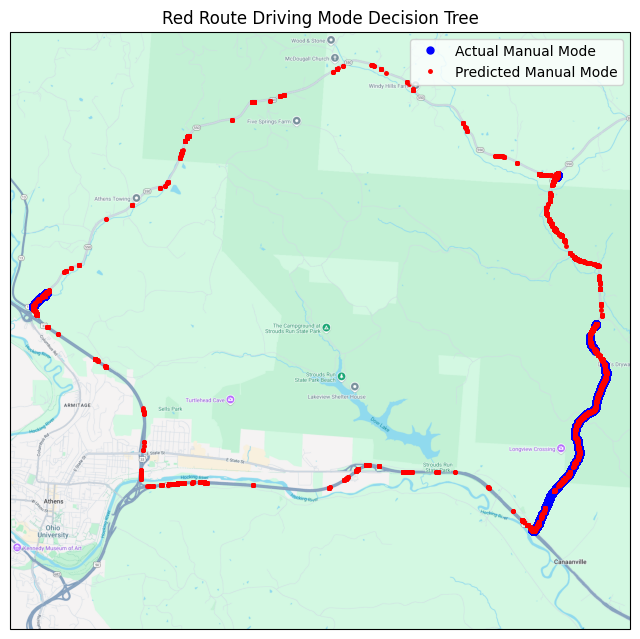

Green Route - 0 [sec] Moving Window

Automatic Precision: 0.899

Manual Precision: 0.790

Automatic Recall: 0.981

Manual Recall: 0.392

Automatic F1-Score: 0.938

Manual F1-Score: 0.524

Driving Mode Accuracy: 0.890

Driving Mode Balanced Accuracy: 0.886

                    Importance
speedMps              0.372081
brakePercentage       0.246964
LatLonTotalStdDev     0.138415
steeringPercentage    0.122350
throttlePercentage    0.120189


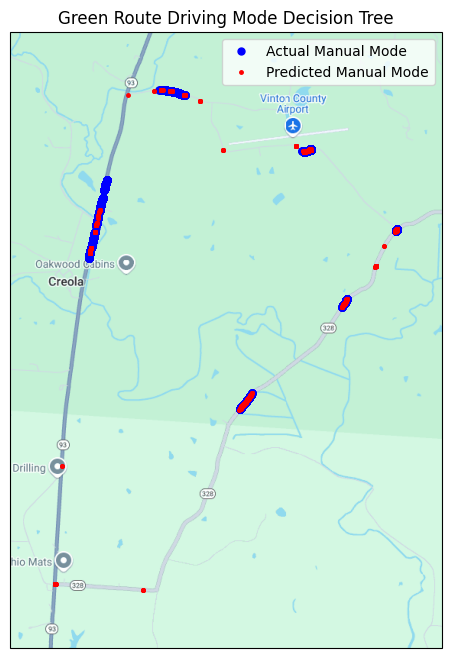

Blue Route - 0 [sec] Moving Window

Automatic Precision: 0.890

Manual Precision: 0.714

Automatic Recall: 0.893

Manual Recall: 0.709

Automatic F1-Score: 0.891

Manual F1-Score: 0.712

Driving Mode Accuracy: 0.842

Driving Mode Balanced Accuracy: 0.803

                    Importance
speedMps              0.488676
brakePercentage       0.248891
steeringPercentage    0.098201
throttlePercentage    0.082656
LatLonTotalStdDev     0.081576


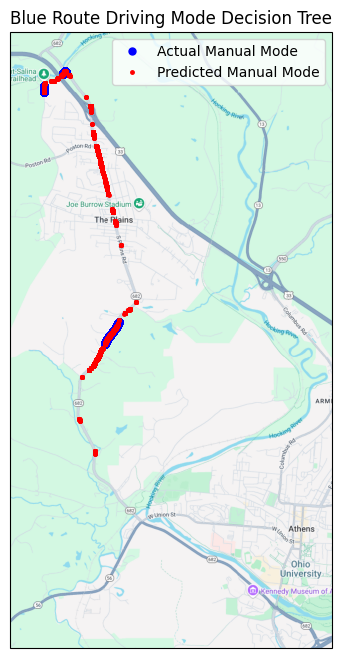

In [24]:
#Do this for every value in "routes"
for route in routes:

    #If the route is red, 

    if ( route == 'Red' ):

        training_gmIDs, testing_gmIDs = red_training_gmIDs, red_testing_gmIDs

        plot_gmID = '5a4bccf4-effe-11ee-b966-fb353e7798cd'

    #Else if the route is green,

    elif ( route == 'Green' ):

        training_gmIDs, testing_gmIDs = green_training_gmIDs, green_testing_gmIDs

        plot_gmID = '5774dcde-f196-11ee-babe-fb353e7798cd'

    #Else if the route is blue,

    elif ( route == 'Blue' ):

        training_gmIDs, testing_gmIDs = blue_training_gmIDs, blue_testing_gmIDs

        plot_gmID = 'da853e0c-a10f-11ee-981c-d126ddbe9afa'

    #Run for every value in "moving_windows"

    for moving_window in moving_windows:

        #Set "training_dfs" and "testing_dfs" each equal to empty lists

        training_dfs, testing_dfs = [], []

        #Run for every value in "training_gmIDs"

        for training_gmID in training_gmIDs:

            training_df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = training_gmID, 
                                                                                 moving_window = moving_window )
            #Append "training_df" to "training_dfs"
            training_dfs.append( training_df )

        #Run for every value in "testing_gmIDs"
        for testing_gmID in testing_gmIDs:

            testing_df = cfs.retrieve_gmID_preprocessed_moving_data_v3( gmID = testing_gmID, 
                                                                                moving_window = moving_window )
            #Append "testing_df" to "testing_dfs"
            testing_dfs.append( testing_df )

        #If "moving_window" is greater than 0,

        if ( moving_window > 0 ):
            #Set "string" equal to "_mean"

            string = '_mean'
            
        #Else, set string equal to " "

        else:

            string = ''

        #For every value "X_colname" in "X_colnames", modify "X_colname" to add the string in the end
        #Save results in "modified_X_colnames"

        modified_X_colnames = [ X_colname + string for X_colname in X_colnames ]

        #

        cm_values, model, y_test, y_pred_test = cfs.BinaryClassification_DecisionTree( train_dfs = training_dfs, \
                                                                                       test_dfs = testing_dfs, \
                                                                                       X_colnames = modified_X_colnames, \
                                                                                       y_colname = y_colname, \
                                                                                       dt_random_state = 0, \
                                                                                       y_labels = [ 0, 1 ], \
                                                                                       **hyperparameter_tuning_results[ f'{ route }_{ moving_window }' ][ 'tuned_hyperparameters' ] )

        #

        testing_df = pd.concat( testing_dfs )

        testing_df[ 'pred_BinaryDrivingMode' ] = y_pred_test

        #

        tn, fp, fn, tp = cm_values.values()

        metrics = cfs.ML_metrics( tn = tn, fp = fp, fn = fn, tp = tp, beta = 1, display = False )

        negative_precision = cfs.mf_negative_precision(tn = tn, fp = fp, fn = fn, tp = tp)
        negative_f1_score = (2*negative_precision*metrics[ 6 ])/(negative_precision+metrics[ 6 ])


        #Print the title for the red route metrics

        print( f'{ route } Route - { moving_window } [sec] Moving Window\n' )
        
        #Print the labels for "Automatic Precision"
        print( f'Automatic Precision: { metrics[ 4 ]:.3f}\n' )
        #Print the labels for "Manual Precision"
        print( f'Manual Precision: { negative_precision:.3f}\n' )

        #Print the labels for "Automatic Recall"
        print( f'Automatic Recall: { metrics[ 5 ]:.3f}\n' )
        #Print the labels for "Manual Recall"
        print( f'Manual Recall: { metrics[ 6 ]:.3f}\n' )

        
        #Print the labels for "Automatic F1-Score"
        print( f'Automatic F1-Score: { metrics[ 7 ]:.3f}\n' )
        #Print the labels for "Manual F1-Score"
        print( f'Manual F1-Score: { negative_f1_score:.3f}\n' )

        #Print the labels for "Driving Mode Accuaracy"
        print( f'Driving Mode Accuracy: { metrics[ 8 ]:.3f}\n' )
        #Print the labels for "Driving Mode Balanced Accuaracy"
        print( f'Driving Mode Balanced Accuracy: { metrics[ 9 ]:.3f}\n' )

        #

        feat_importances = pd.DataFrame( model.feature_importances_, index = X_colnames, columns = [ "Importance" ] )

        feat_importances.sort_values( by = 'Importance', ascending = False, inplace = True )

        #Print "feat_importances"

        print( feat_importances )

        #

        
        #

        testing_df_copy = testing_df[ testing_df[ 'groupMetadataID' ] == plot_gmID ]

        #

        prepare_map_settings( route_color = route )

        #

        actual_manual_lat_list_test =  testing_df_copy[ testing_df_copy[ 'BinaryDrivingMode' ] == 0 ][ 'latitude' ]

        actual_manual_lon_list_test =  testing_df_copy[ testing_df_copy[ 'BinaryDrivingMode' ] == 0 ][ 'longitude' ]

        #

        pred_manual_lat_list_test =  testing_df_copy[ testing_df_copy[ 'pred_BinaryDrivingMode' ] == 0 ][ 'latitude' ]

        pred_manual_lon_list_test =  testing_df_copy[ testing_df_copy[ 'pred_BinaryDrivingMode' ] == 0 ][ 'longitude' ]

        #

        plt.plot( actual_manual_lon_list_test, 
                  actual_manual_lat_list_test, 
                  transform = ccrs.PlateCarree(), 
                  marker = 'o', 
                  ls = '', 
                  color = 'blue',  
                  ms = 5, 
                  label = 'Actual Manual Mode' )

        plt.plot( pred_manual_lon_list_test, 
                  pred_manual_lat_list_test, 
                  transform = ccrs.PlateCarree(), 
                  marker = 'o', 
                  ls = '', 
                  color = 'red', 
                  ms = 2.5,
                  label = 'Predicted Manual Mode' )

        plt.title( f'{ route } Route Driving Mode Decision Tree' )

        #Add a legend to the plot

        plt.legend( )

        #Show plot

        plt.show()

In [17]:
#Create a function called "prepare_map_settings", with "route_color" as the input
def prepare_map_settings( route_color ):

    plt.figure( figsize = ( 8, 8 ) )

    #If the "red_color" value is red, set the "minLat" value to 39.3124906671225, the "maxLat" value to 39.40448581121833, 
    #the "minLon" value to -82.10582075491102, and the "maxLon" value to -81.9788697421841

    if ( route_color == 'Red' ):

        minLat, maxLat = 39.3124906671225, 39.40448581121833
        
        minLon, maxLon = -82.10582075491102, -81.9788697421841

    #If the "route_color" value is red, set the "minLat" value to 39.28843222457655, the "maxLat" value to 39.33215131664078, 
    #the "minLon" value to -82.46754600607878, and the "maxLon" value to -82.4289058208249

    elif ( route_color == 'Green' ):

        minLat, maxLat = 39.28843222457655, 39.33215131664078
        
        minLon, maxLon = -82.46754600607878, -82.4289058208249

    #If the "route_color" value is green, set the "minLat" value to 39.31899122387631, the "maxLat" value to 39.38797086107572, 
    #the "minLon" value to -82.14449476722909, and the "maxLon" value to -82.10122278485707

    elif ( route_color == 'Blue' ):

        minLat, maxLat = 39.31899122387631, 39.38797086107572
        
        minLon, maxLon = -82.14449476722909, -82.10122278485707

    #Set "expansion_coeff" equal to .005

    expansion_coeff = 0.005

    #

    street_map = GoogleTiles( style = 'street' )

    ax = plt.axes( projection = street_map.crs )

    ax.set_extent( [ minLon - expansion_coeff , \
                     maxLon + expansion_coeff, \
                     minLat - expansion_coeff, \
                     maxLat + expansion_coeff ], \
                     ccrs.PlateCarree() )

    ax.add_image( street_map, 14 )